## Imports

In [1]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt
from models.vae import VAE,vae_loss_function
import os
import pandas as pd
import torch
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm # Use notebook version for cleaner UI
import seaborn as sns

## Data Loading

In [2]:
path = "./data"
print("Path to dataset files : ",path)
# Paths to the CSV files
train_csv_path = os.path.join(path, 'train.csv')
test_csv_path = os.path.join(path, 'test.csv')

image_dir = os.path.join(path, 'faces')

df_train = pd.read_csv(train_csv_path)
df_train['id'] = df_train['id'].astype(int).astype(str)
df_train['id'] = 'face-'+df_train['id']+'.png'

df_test = pd.read_csv(test_csv_path)
df_test['id'] = df_test['id'].astype(int).astype(str)
df_test['id'] = 'face-'+df_test['id']+'.png'

print(f"Total images found in train.csv: {len(df_train)}")
print(f"Total images found in train.csv: {len(df_test)}")

Path to dataset files :  ./data
Total images found in train.csv: 4500
Total images found in train.csv: 500


## Image Downscaling

In [3]:
final_dim = 64
processed_dir = path + "/faces_processed_" + str(final_dim)
if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)


# Define your interval (e.g., every 50 images)
progress_interval = 50 
count = 0

# Correcting the concat syntax: it needs a list [df_train, df_test]
combined_df = pd.concat([df_train, df_test])
total_images = len(combined_df)

print(f"Resizing images to {final_dim}x{final_dim}...")

for index, row in combined_df.iterrows():
    filename = row['id']
    input_path = os.path.join(image_dir, filename)
    output_path = os.path.join(processed_dir, filename)
    
    # 1. Check if the file already exists in the output directory
    if os.path.exists(output_path):
        count += 1
        continue # Skip to the next image
    
    img = cv2.imread(input_path)
    
    if img is not None:
        resized_img = cv2.resize(img, (final_dim, final_dim), interpolation=cv2.INTER_AREA)
        cv2.imwrite(output_path, resized_img)
        count += 1
        
        # 2. Progress indicator with custom counter
        if count % progress_interval == 0 or count == total_images:
            print(f"Progress: {count}/{total_images} images processed.")
    else:
        print(f"Warning: Could not read {filename} at {input_path}")
        count += 1

print(f"Successfully saved resized images to {processed_dir}")

Resizing images to 64x64...
Successfully saved resized images to ./data/faces_processed_64


## Dataset Creation and Image Augmentation

In [4]:
class FacesDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, label_col='glasses'):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        # 1. Get the filename and label from your pandas dataframe
        img_name = self.dataframe.iloc[idx]['id'] 
        label = self.dataframe.iloc[idx][self.label_col]

        # 2. Load the image
        img_path = os.path.join(self.image_dir, img_name)
        image = cv2.imread(img_path)
        
        # Convert BGR (OpenCV default) to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 3. Apply transformations (like converting to PyTorch Tensor)
        if self.transform:
            transformed = self.transform(image=image)
            image = transformed["image"]

        # 4. Return the image tensor and the label
        return image, torch.tensor(label, dtype=torch.float32)

In [5]:
# Define the Albumentations pipeline
albumentations_transform = A.Compose([
    # 1. Rotation, Scaling, Translation
    # border_mode=cv2.BORDER_REFLECT_101 handles the padding automatically
    A.ShiftScaleRotate(
        shift_limit=0.02, 
        scale_limit=0.05, 
        rotate_limit=5, 
        border_mode=cv2.BORDER_REFLECT_101, 
        p=0.8
    ),
    
    # 2. Random Cropping via Padding
    # Pad to 68x68 using reflection, then crop a random 64x64 section
    A.PadIfNeeded(min_height=68, min_width=68, border_mode=cv2.BORDER_REFLECT_101, p=1.0),
    A.RandomCrop(height=64, width=64, p=1.0),
    
    # 3. Horizontal Flip
    A.HorizontalFlip(p=0.5),
    
    # 4. Color Jitter
    A.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.0, p=0.5),
    
    # 5. Conversion to PyTorch Tensor
    # Albumentations requires explicit division by 255 to match torchvision's [0, 1] scaling
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
    ToTensorV2()
])

/home/crisp/Projects/Gen AI - A1/.venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [6]:

# The ToTensor transform automatically converts the numpy array to a CHW tensor 
# and scales the pixels to a 0-1 range.

# Define the aggressive (but safe) augmentation pipeline
augmented_transform = transforms.Compose([
    transforms.ToPILImage(), # Required because OpenCV returns NumPy arrays
    
    # 1. Rotation, Translation, and Scaling
    # Rotates up to 12 degrees, shifts by 5%, scales between 90% and 110%
    transforms.RandomAffine(degrees=5, translate=(0.02, 0.02), scale=(0.9, 1.1)),
    
    # 2. Random Cropping
    # Pads the edges by 4 pixels by reflecting the border, then crops a random 64x64 section
    transforms.RandomCrop(64, padding=4, padding_mode='reflect'),
    
    # 3. Flipping
    # Faces are mostly symmetrical, so this instantly doubles your dataset variations
    transforms.RandomHorizontalFlip(p=0.5),
    
    # 4. Color Jitter
    # Slight changes to lighting and contrast to prevent overfitting to specific photo conditions
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    
    transforms.ToTensor() # Converts back to [0.0, 1.0] tensor
])

In [7]:

# Update your dataset to use this new transform
train_dataset = FacesDataset(
    dataframe=combined_df, 
    image_dir=processed_dir, 
    transform=albumentations_transform,
    label_col='glasses' 
)


# Create the DataLoader
batch_size = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, # Shuffle the data every epoch for better generalization
    num_workers=2, # Uses background CPU threads to load images faster
    pin_memory=True # Speeds up transfer from CPU RAM to GPU VRAM
)

print(f"Total batches per epoch: {len(train_loader)}")

Total batches per epoch: 79


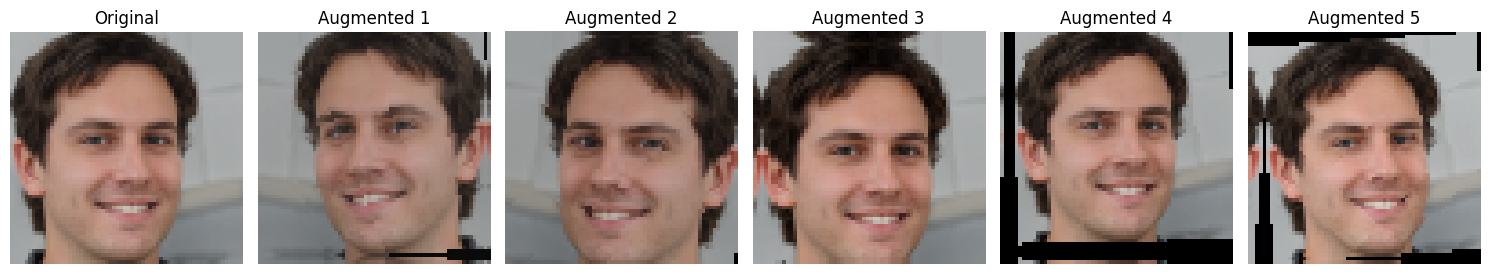

In [8]:

# Fetch one specific image and label from the raw dataset (bypassing the transform temporarily)
sample_img_name = df_train.iloc[0]['id']
raw_img = cv2.imread(os.path.join(processed_dir, sample_img_name))
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 3))

# Plot Original
plt.subplot(1, 6, 1)
plt.imshow(raw_img)
plt.title("Original")
plt.axis('off')

# Plot 5 Augmented Versions
for i in range(5):
    # Apply the transform
    aug_tensor = augmented_transform(raw_img)
    # Convert back to HWC format for matplotlib
    aug_img = aug_tensor.permute(1, 2, 0).numpy()
    
    plt.subplot(1, 6, i+2)
    plt.imshow(aug_img)
    plt.title(f"Augmented {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## VAE Training

In [10]:


# 1. Setup Optimizer and Epochs
# A learning rate of 1e-3 is standard for Adam with VAEs
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 10 # Start with 15 to see how long it takes on your GPU

# List to store average loss per epoch for your ablation plots
epoch_losses = []

print(f"Starting training on {device}...")

for epoch in range(epochs):
    model.train()
    train_loss = 0
    
    # Wrap your loader in tqdm for the progress bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
    
    for batch_idx, (data, labels) in enumerate(progress_bar):
        # Move the image batch to the RTX 3060 VRAM
        data = data.to(device)
        
        # Inject Gaussian Noise (mean 0, std 0.1)
        # torch.clamp ensures pixel values don't exceed the [0, 1] bounds
        noisy_data = data + torch.randn_like(data) * 0.1
        noisy_data = torch.clamp(noisy_data, 0., 1.)
        # Reset the gradients
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data)
        
        # Calculate loss (Ensure vae_loss_function is imported)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        
        # Backward pass (calculate gradients)
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        train_loss += loss.item()
        
        # Update the progress bar with the current batch loss
        # We divide by batch size (data.size(0)) to get average loss per image
        progress_bar.set_postfix({'Loss': f"{loss.item() / data.size(0):.4f}"})
        
    # Calculate average loss for the entire epoch
    avg_loss = train_loss / len(train_loader.dataset)
    epoch_losses.append(avg_loss)
    
    print(f"Epoch {epoch+1} Completed | Average Loss: {avg_loss:.4f}")

print("Training finished!")

Starting training on cuda...


Epoch 1/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1 Completed | Average Loss: 8064.7146


Epoch 2/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2 Completed | Average Loss: 7628.8000


...

Epoch 8 Completed | Average Loss: 7423.4032


Epoch 9/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 9 Completed | Average Loss: 7412.3686


Epoch 10/10:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 10 Completed | Average Loss: 7403.2862
Training finished!


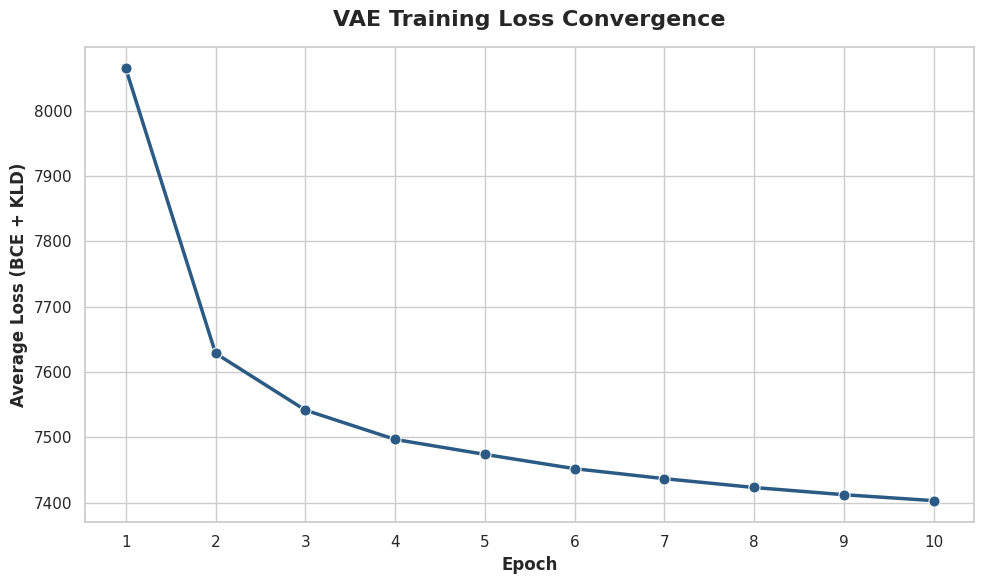

In [11]:


# Set a professional seaborn theme
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the epoch_losses list we populated during training
sns.lineplot(
    x=range(1, len(epoch_losses) + 1), 
    y=epoch_losses, 
    marker='o', 
    linewidth=2.5, 
    markersize=8,
    color='#2b5b84' # A clean, academic blue
)

# Format the labels and title
plt.title('VAE Training Loss Convergence', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Average Loss (BCE + KLD)', fontsize=12, fontweight='bold')

# Ensure the x-axis only shows whole integer epochs
plt.xticks(range(1, len(epoch_losses) + 1))

plt.tight_layout()

# Save the plot to your directory so you can drop it into your report
plt.savefig('vae_training_loss.png', dpi=300)

# Display the plot in the notebook
plt.show()

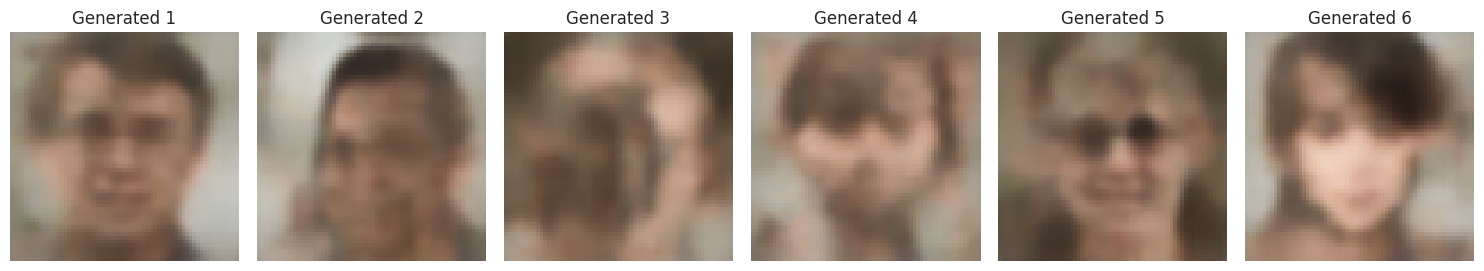

In [12]:
# Switch model to evaluation mode (turns off dropout/batchnorm if you add them later)
model.eval()

with torch.no_grad(): # Do not track gradients for generation
    # Sample 6 random vectors from a standard normal distribution
    # latent_dim should match what you initialized the model with (e.g., 128)
    sample_z = torch.randn(6, 128).to(device)
    
    # Pass them through the decoder
    generated_images = model.decoder(model.fc_decode(sample_z)).cpu()

    # Plot the results
    plt.figure(figsize=(15, 5))
    for i in range(6):
        plt.subplot(1, 6, i+1)
        # Permute from PyTorch format (C, H, W) to Matplotlib format (H, W, C)
        img_to_show = generated_images[i].permute(1, 2, 0).numpy()
        plt.imshow(img_to_show)
        plt.axis('off')
        plt.title(f"Generated {i+1}")
        
    plt.tight_layout()
    plt.show()

Extracting latent vectors...


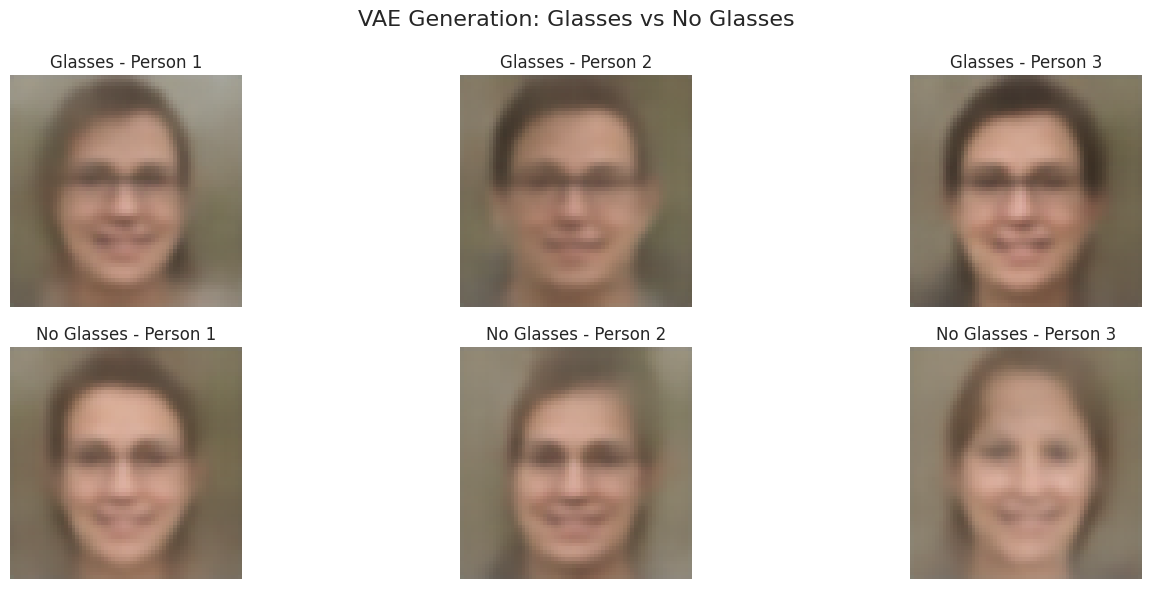

In [13]:
def get_average_latents(model, dataloader, device):
    model.eval()
    mu_glasses = []
    mu_no_glasses = []
    
    print("Extracting latent vectors...")
    with torch.no_grad():
        for data, labels in dataloader:
            data = data.to(device)
            # Pass through the encoder and the mu linear layer
            encoded = model.encoder(data)
            mu = model.fc_mu(encoded)
            
            # Sort by label
            for i in range(len(labels)):
                if labels[i].item() == 1.0: # 1 = Glasses
                    mu_glasses.append(mu[i])
                else:
                    mu_no_glasses.append(mu[i])
                    
    # Stack the lists into tensors and calculate the mean across all images
    avg_glasses = torch.stack(mu_glasses).mean(dim=0)
    avg_no_glasses = torch.stack(mu_no_glasses).mean(dim=0)
    
    return avg_glasses, avg_no_glasses

# 1. Get the average vectors
avg_glasses, avg_no_glasses = get_average_latents(model, train_loader, device)

# 2. Create 3 variations for each class
# We duplicate the average vector 3 times, then add a small amount of random noise (scale=0.5) 
# to generate distinct faces that share the core "glasses" or "no glasses" traits.
latent_dim = 128 # Ensure this matches your model
noise_scale = 0.5

z_glasses = avg_glasses.unsqueeze(0).repeat(3, 1) + (torch.randn(3, latent_dim).to(device) * noise_scale)
z_no_glasses = avg_no_glasses.unsqueeze(0).repeat(3, 1) + (torch.randn(3, latent_dim).to(device) * noise_scale)

# Combine them into one batch of 6
z_combined = torch.cat([z_glasses, z_no_glasses], dim=0)

# 3. Decode and visualize
with torch.no_grad():
    generated_images = model.decoder(model.fc_decode(z_combined)).cpu()

plt.figure(figsize=(15, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    img_to_show = generated_images[i].permute(1, 2, 0).numpy()
    plt.imshow(img_to_show)
    plt.axis('off')
    title = "Glasses" if i < 3 else "No Glasses"
    plt.title(f"{title} - Person {i%3 + 1}")

plt.suptitle("VAE Generation: Glasses vs No Glasses", fontsize=16)
plt.tight_layout()
plt.show()

## GAN Training